# Fingerprint-based similarity scores - use for dimensionality reduction plots


## Data

Here we use the **ms2structures dataset** containing 37,811 unique compounds.

In [1]:
import os
import sys
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

from rdkit.Chem import rdFingerprintGenerator

ROOT = Path(os.getcwd()).parents[0]
path_data = os.path.join(Path(ROOT), "data")

In [2]:
filename = "compounds_ms2structures.csv"
compounds = pd.read_csv(os.path.join(path_data, filename))
compounds.head()

,inchikey,smiles,mass,cf_class,cf_subclass,cf_superclass,formula,npc_class_results,npc_pathway_results,npc_superclass_results
0,AAAQFGUYHFJNHI,CCNC(=O)C[C@H]1C2=NN=C(N2C3=C(C=C(C=C3)OC)C(=N...,423.146204,Benzodiazepines,"1,4-benzodiazepines",Organoheterocyclic compounds,C22H22ClN5O2,NaN,Alkaloids,NaN
1,AABFWJDLCCDJJN,COC1=CC2=C(C=C1)NC3=C2C=CN=C3C4=CC=CC5=CC=CC=C54,324.126264,Harmala alkaloids,NaN,Alkaloids and derivatives,C22H16N2O,Carboline alkaloids,Alkaloids,Tryptophan alkaloids
2,AABILZKQMVKFHP,C/C=C(/C)\C(=O)O[C@H]1CC[N+]2([C@@H]1C(=CC2)CO...,427.220624,NaN,NaN,Alkaloids and derivatives,C21H33NO8,Pyrrolizidine alkaloids,Alkaloids,Ornithine alkaloids
3,AABUHSBGEIUSRJ,CC(=O)NC1=CC=C(C=C1)NC(=O)C=CC2=CC=CC=C2,280.120724,Cinnamic acids and derivatives,Cinnamic acid amides,Phenylpropanoids and polyketides,C17H16N2O2,Cinnamic acid amides,Shikimates and Phenylpropanoids,Phenylpropanoids (C6-C3)
4,AABUKWVVUWBZCS,C1=CC=C(C=C1)C2=C(C(=O)OC3=C2C=CC(=C3)O)C4=CC=...,314.094724,Neoflavonoids,Neoflavones,Phenylpropanoids and polyketides,C21H14O3,Neoflavonoids,Shikimates and Phenylpropanoids,Flavonoids


In [3]:
compounds.shape

(37811, 10)

In [4]:
compounds.value_counts("cf_superclass")

cf_superclass
Organoheterocyclic compounds                 10423
Lipids and lipid-like molecules               7496
Benzenoids                                    6608
Organic acids and derivatives                 5330
Phenylpropanoids and polyketides              3937
Organic oxygen compounds                      1599
Alkaloids and derivatives                     1003
Organic nitrogen compounds                     531
Nucleosides, nucleotides, and analogues        314
Lignans, neolignans and related compounds      233
Organosulfur compounds                         197
Organic Polymers                                35
Organohalogen compounds                         32
Organophosphorus compounds                      21
Hydrocarbon derivatives                         19
Organometallic compounds                        10
Hydrocarbons                                     9
Organic 1,3-dipolar compounds                    7
Homogeneous non-metal compounds                  6
Name: count, dtyp

In [6]:
compounds.value_counts("cf_class").head(20)

cf_class
Benzene and substituted derivatives    5108
Carboxylic acids and derivatives       4575
Prenol lipids                          2591
Fatty Acyls                            1663
Organooxygen compounds                 1596
Glycerophospholipids                   1439
Steroids and steroid derivatives       1263
Indoles and derivatives                1219
Flavonoids                             1097
Quinolines and derivatives              979
Azoles                                  940
Coumarins and derivatives               715
Pyridines and derivatives               682
Benzopyrans                             614
Organonitrogen compounds                531
Diazanaphthalenes                       521
Diazinanes                              505
Diazines                                450
Piperidines                             414
Peptidomimetics                         381
Name: count, dtype: int64

## Compute fingerprints
Circular fingerprints --> and variants

In [7]:
from chemap.fingerprint_statistics import unfolded_count_fingerprint_bit_statistics
from chemap import metrics
from chemap.fingerprint_computation import compute_fingerprints, FingerprintConfig

# Brute-force NN computation

In [8]:
from scipy.sparse import lil_matrix


def compute_knn(vectors, similarity_measure, weights=None, max_batch=1000, n_neighbors=100):
    n_splits = int(np.ceil(len(vectors) / max_batch))

    knn_indices = np.zeros((len(vectors), n_neighbors), dtype=np.int32)
    knn_dists= np.zeros((len(vectors), n_neighbors), dtype=np.float32)
    
    for i in tqdm(range(n_splits)):
        start_i, end_i = i * max_batch, min((i + 1) * max_batch, len(vectors))

        sub_vectors_i = vectors[start_i:end_i]

        # Compute the similarity between the sub-vectors
        if weights is not None:
            distances = 1 - similarity_measure(sub_vectors_i, vectors, weights)
        else:
            distances = 1 - similarity_measure(sub_vectors_i, vectors)
            
        # Get the indices of the nearest neighbors (including the point itself)
        knn_indices[start_i:end_i, :] = np.argsort(distances, axis=1)[:, :n_neighbors]

        # Sort the distances accordingly
        knn_dists[start_i:end_i, :] = np.sort(distances, axis=1)[:, :n_neighbors]

    return knn_indices, knn_dists


# Morgan-3 count sparse

In [108]:
# config for simple count fingerprints
config = FingerprintConfig(
    count=True,
    folded=False,
    invalid_policy="raise",
)

In [9]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=4096)

fingerprints_morgan3_sparse = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [00:06<00:00, 6213.22it/s]


## Comparison 3: Morgan-9 count sparse

In [10]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=4096)

fingerprints_morgan9_sparse = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [00:07<00:00, 5140.94it/s]


## IDF

In [48]:
NUM_COMPOUNDS = compounds.shape[0]

In [49]:
def idf_normalized(df, N):
    def formula(x, N):
        return np.log(N / x)

    max_idf = formula(1, N)
    return formula(df, N) / max_idf

In [128]:
unique_keys, counts, first_instances = unfolded_count_fingerprint_bit_statistics(fingerprints_morgan3_sparse)

idx = np.where(counts > 1)[0]
bit_weighing = {unique_keys[i]: idf_normalized(counts[i], num_compounds) for i in idx}

# config for TFIDF count fingerprints
config = FingerprintConfig(
    count=True,
    folded=False,
    unfolded_weights=bit_weighing,
    invalid_policy="raise",
)

In [129]:
# Compute fingerprints
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=4096)

fingerprints_morgan3_sparse_tfidf = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [00:06<00:00, 5506.49it/s]


In [130]:
unique_keys, counts, first_instances = unfolded_count_fingerprint_bit_statistics(fingerprints_morgan9_sparse)

idx = np.where(counts > 1)[0]
bit_weighing = {unique_keys[i]: idf_normalized(counts[i], num_compounds) for i in idx}

# config for TFIDF count fingerprints
config = FingerprintConfig(
    count=True,
    folded=False,
    unfolded_weights=bit_weighing,
    invalid_policy="raise",
)

In [131]:
# Compute fingerprints
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=4096)

fingerprints_morgan9_sparse_tfidf = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [00:08<00:00, 4341.60it/s]


In [132]:
fingerprints_morgan9_sparse_tfidf[0][1]

array([0.6773166 , 0.6388487 , 0.93423873, 0.78154576, 0.66001916,
       0.93423873, 0.93423873, 0.16655803, 0.93423873, 0.546588  ,
       0.55404913, 1.        , 0.86847746, 0.93423873, 0.23665679,
       0.5346196 , 0.93423873, 0.81538475, 1.        , 0.93423873,
       0.54901046, 0.10368622, 0.06827585, 0.01646161, 0.72065085,
       0.27498558, 0.63076955, 1.        , 0.08789884, 0.2243842 ,
       1.        , 0.93423873, 0.93423873, 0.89577085, 0.61155534,
       0.27695084, 0.93423873, 1.        , 0.7915417 , 1.        ,
       0.04427375, 0.93423873, 1.        , 0.36580774, 1.        ,
       0.53253436, 0.73120326, 0.93423873, 0.37512615, 0.170774  ,
       0.11331196, 0.93423873, 0.4870029 , 1.        , 0.07254819,
       0.30232692, 0.039666  , 0.06381058, 0.22646348, 1.        ,
       0.7157845 , 0.7067421 , 0.73120326, 0.93423873, 0.7642483 ,
       0.89577085, 0.37902   , 1.        , 0.93423873, 1.        ,
       0.847307  , 0.6147717 , 0.5982956 , 0.37915644, 0.89577

In [133]:
df_weighing = pd.DataFrame({
    "bit": list(bit_weighing.keys()),
    "idf_weighing": list(bit_weighing.values())
}).set_index("bit")
df_weighing.sort_values("idf_weighing")

,idf_weighing
bit,
864942730,0.016462
3217380708,0.019082
2246728737,0.021270
3218693969,0.024551
2245384272,0.036274
...,...
4294591349,0.934239
34940,0.934239
4294701792,0.934239


## Compute exact nearest neighbor tree
(for larger dataset better switch to ANN)

In [12]:
%%time

knn_indices_morgan3, knn_dists_morgan3 = compute_knn(
    fingerprints_morgan3_sparse,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


CPU times: user 11min 40s, sys: 7.04 s, total: 11min 47s
Wall time: 1min 10s


In [13]:
%%time

knn_indices_morgan9, knn_dists_morgan9 = compute_knn(
    fingerprints_morgan9_sparse,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

CPU times: user 18min 24s, sys: 8.38 s, total: 18min 32s
Wall time: 1min 46s


In [134]:
%%time

knn_indices_m3_tfidf, knn_dists_m3_tfidf = compute_knn(
    fingerprints_morgan3_sparse_tfidf,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

CPU times: user 11min 39s, sys: 6.59 s, total: 11min 46s
Wall time: 1min 10s


In [135]:
%%time

knn_indices_m9_tfidf, knn_dists_m9_tfidf = compute_knn(
    fingerprints_morgan9_sparse_tfidf,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

CPU times: user 18min 23s, sys: 7.68 s, total: 18min 31s
Wall time: 1min 46s


# RDKit count sparse

In [109]:
# config for simple count fingerprints
config = FingerprintConfig(
    count=True,
    folded=False,
    invalid_policy="raise",
)

In [110]:
fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096)

fingerprints_rdkit_sparse = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [00:51<00:00, 735.11it/s]


## IDF

In [122]:
unique_keys, counts, first_instances = unfolded_count_fingerprint_bit_statistics(fingerprints_rdkit_sparse)

idx = np.where(counts > 1)[0]
bit_weighing = {unique_keys[i]: idf_normalized(counts[i], num_compounds) for i in idx}

df_weighing = pd.DataFrame({
    "bit": list(bit_weighing.keys()),
    "idf_weighing": list(bit_weighing.values())
}).set_index("bit")
df_weighing.sort_values("idf_weighing")

,idf_weighing
bit,
4275705116,0.012133
986785516,0.012133
54413874,0.027811
4274652475,0.027811
1940446997,0.029768
...,...
1072900591,0.934239
1072906313,0.934239
1072934666,0.934239


In [126]:
# config for TFIDF count fingerprints
config = FingerprintConfig(
    count=True,
    folded=False,
    unfolded_weights=bit_weighing,
    invalid_policy="raise",
)

In [127]:
%%time

# Compute fingerprints
fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096)

fingerprints_rdkit_sparse_tfidf = compute_fingerprints(
    compounds.smiles,
    fpgen,
    config=config,
    show_progress=True,
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37811/37811 [01:11<00:00, 527.69it/s]

CPU times: user 1min 11s, sys: 238 ms, total: 1min 11s
Wall time: 1min 11s


In [137]:
fingerprints_rdkit_sparse_tfidf[0][1]

array([1.1685239 , 0.23732792, 0.73120326, ..., 0.46574745, 1.9201312 ,
       0.7725034 ], shape=(1998,), dtype=float32)

## Compute exact nearest neighbor tree
(for larger dataset better switch to ANN)

In [114]:
%%time

knn_indices_rdkit, knn_dists_rdkit = compute_knn(
    fingerprints_rdkit_sparse,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

CPU times: user 2h 39min 5s, sys: 21.7 s, total: 2h 39min 27s
Wall time: 11min 30s


In [147]:
%%time

knn_indices_rdkit_tfidf, knn_dists_rdkit_tfidf = compute_knn(
    fingerprints_rdkit_sparse_tfidf,
    metrics.generalized_tanimoto_similarity_matrix_sparse,
    max_batch=3000
)

  0%|          | 0/13 [00:00<?, ?it/s]

CPU times: user 2h 39min 32s, sys: 22 s, total: 2h 39min 54s
Wall time: 11min 44s


In [148]:
path_knn = "/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/knn_computations/"

with open(os.path.join(path_knn, 'knng_rdkit_tfidf_ms2structures_sparse.pickle'), 'wb') as handle:
    pickle.dump([knn_indices_rdkit_tfidf, knn_dists_rdkit_tfidf], handle, protocol=pickle.HIGHEST_PROTOCOL)

In [146]:
with open(os.path.join(path_knn, 'knng_rdkit_tfidf_ms2structures_sparse.pickle'), 'rb') as handle:
    (knn_indices_rdkit_tfidf, knn_dists_rdkit_tfidf) = pickle.load(handle)

In [17]:
def knn_label_match_fraction(df, nbr_idx, label_col, ignore_nan_query=True):
    """
    Returns:
      frac_per_row: float array (n,) with fraction of neighbors matching the query label
      overall_mean: scalar mean of frac_per_row (optionally excluding NaN query labels)
    Notes:
      - If a query label is NaN and ignore_nan_query=True, that row becomes NaN.
      - Neighbors with NaN label simply count as non-matching.
    """
    labels = df[label_col].to_numpy()  # dtype object (strings) or similar
    query = labels[:, None]            # (n, 1)
    neigh = labels[nbr_idx]            # (n, k)

    matches = (neigh == query)         # (n, k) boolean; NaNs won't match anything

    frac_per_row = matches.mean(axis=1)

    if ignore_nan_query:
        q_is_nan = (df[label_col].isna().to_numpy())
        frac_per_row = frac_per_row.astype(float)
        frac_per_row[q_is_nan] = np.nan
        overall_mean = np.nanmean(frac_per_row)
    else:
        overall_mean = frac_per_row.mean()

    return 100 * frac_per_row, 100 * overall_mean

In [149]:
experiments = {
    "morgan3": knn_indices_morgan3,
    "morgan9": knn_indices_morgan9,
    "morgan3_tfidf": knn_indices_m3_tfidf,
    "morgan9_tfidf": knn_indices_m9_tfidf,
    "rdkit": knn_indices_rdkit,
    "rdkit_tfidf": knn_indices_rdkit_tfidf,
}

In [150]:
result_dict = {
    key: {} for key in experiments.keys()
}

In [151]:
ks = [1, 2, 3, 5, 10, 20, 30, 50, 75, 100]

for name, knn_indices in tqdm(experiments.items()):
    result_dict[name]["superclass"] = []
    result_dict[name]["class"] = []
    result_dict[name]["per_class"] = {}
    
    for k in ks:
        # Select k nearest neighbors (excluding datapoint itself)
        nbr = knn_indices[:, 1:k+1]
        result_dict[name]["per_class"][k] = {}
        
        # Compute nn class matches
        frac_sc, mean_sc = knn_label_match_fraction(compounds, nbr, "cf_superclass")
        frac_cls, mean_cls = knn_label_match_fraction(compounds, nbr, "cf_class")

        for label in compounds.cf_class.value_counts().index:
            idx = np.where(compounds.cf_class.values == label)[0]
            result_dict[name]["per_class"][k][label] = frac_cls[idx][~np.isnan(frac_cls[idx])].mean()
                
        result_dict[name]["superclass"].append(mean_sc)
        result_dict[name]["class"].append(mean_cls)


  0%|          | 0/6 [00:00<?, ?it/s]

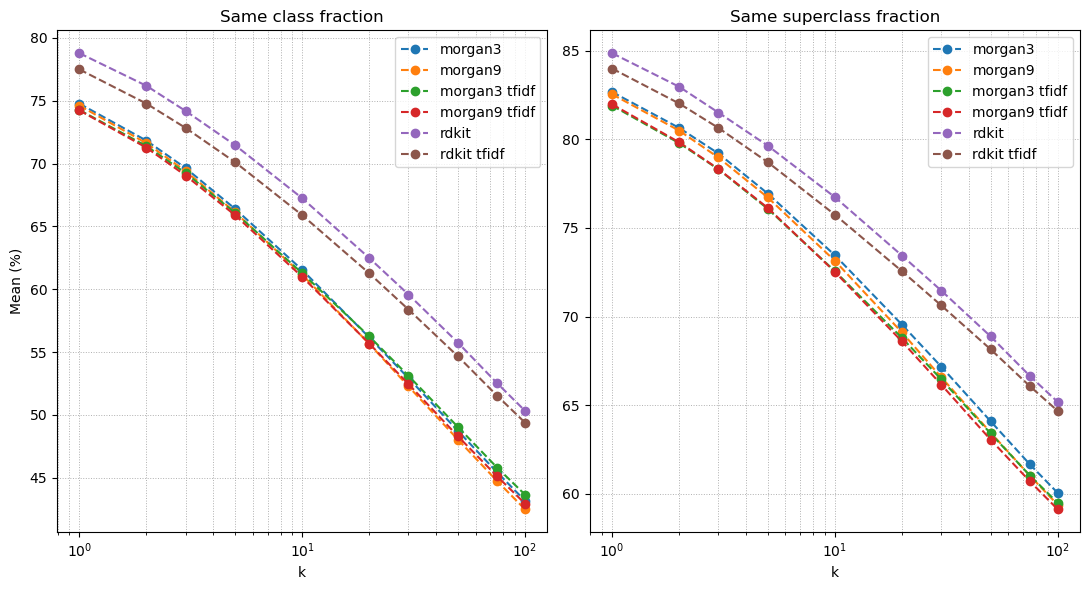

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharex=True)

# Panel 1: same class fraction
ax = axes[0]
for exp_name, exp_data in result_dict.items():
    ax.plot(ks, exp_data["class"], linestyle="--", marker="o", label=exp_name.replace("_", " "))
ax.set_title("Same class fraction")
ax.set_xlabel("k")
ax.set_ylabel("Mean (%)")
ax.set_xscale("log")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.legend()

# Panel 2: same superclass fraction
ax = axes[1]
for exp_name, exp_data in result_dict.items():
    ax.plot(ks, exp_data["superclass"], linestyle="--", marker="o", label=exp_name.replace("_", " "))
ax.set_title("Same superclass fraction")
ax.set_xlabel("k")
ax.set_xscale("log")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.legend()

fig.tight_layout()
plt.show()

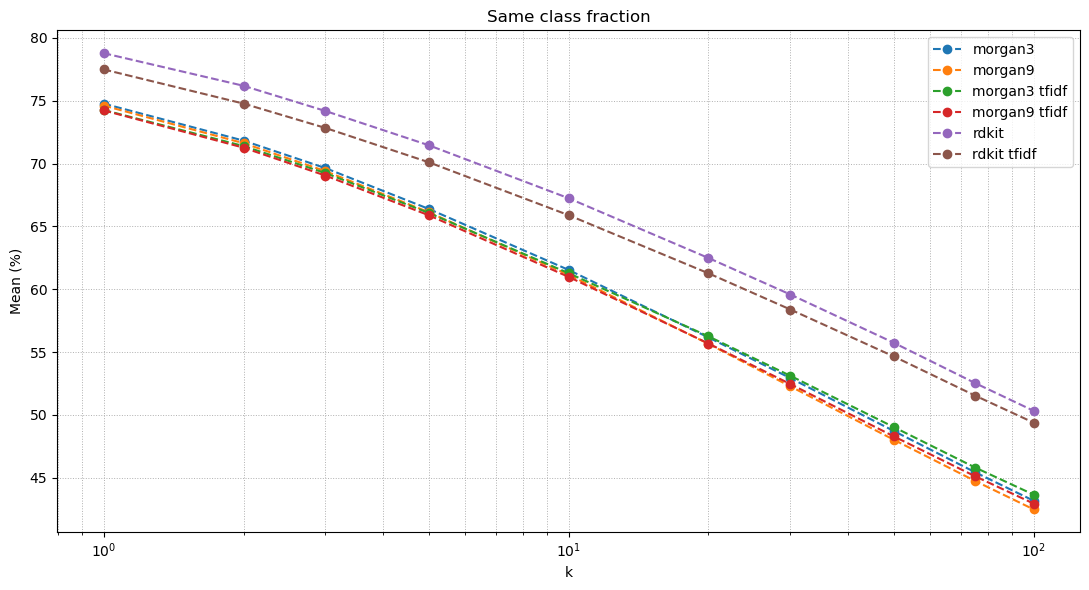

In [153]:
fig, ax = plt.subplots(figsize=(11, 6), sharex=True)

# Panel 1: same class fraction
for exp_name, exp_data in result_dict.items():
    ax.plot(ks, exp_data["class"], linestyle="--", marker="o", label=exp_name.replace("_", " "))
ax.set_title("Same class fraction")
ax.set_xlabel("k")
ax.set_ylabel("Mean (%)")
ax.set_xscale("log")
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.legend()

fig.tight_layout()
plt.show()

In [232]:
k = 100

df_per_class = pd.DataFrame({
    key: result_dict[key]["per_class"][k] for key in experiments.keys()
})
df_per_class["counts"] = compounds.value_counts("cf_class")

base_keys = []
for key in experiments.keys():
    base_keys.append(key.split("_")[0])

for key in set(base_keys):
    df_per_class[f"IDF_induced_shift_{key}"] = df_per_class[f"{key}_tfidf"].values - df_per_class[key]

df_per_class["max_shift"] = df_per_class.iloc[:, -len(set(base_keys)):].max(axis=1)

df_per_class.iloc[:30, :]

,morgan3,morgan9,morgan3_tfidf,morgan9_tfidf,rdkit,rdkit_tfidf,counts,IDF_induced_shift_morgan3,IDF_induced_shift_morgan9,IDF_induced_shift_rdkit,max_shift
Benzene and substituted derivatives,49.319349,50.545589,46.841951,47.786400,56.830442,52.938350,5108,-2.477397,-2.759189,-3.892092,-2.477397
Carboxylic acids and derivatives,63.928907,62.457802,63.605453,61.640890,64.000221,62.841530,4575,-0.323453,-0.816912,-1.158691,-0.323453
Prenol lipids,68.434636,68.493113,68.523522,68.688038,65.881899,66.091248,2591,0.088886,0.194925,0.209349,0.209349
Fatty Acyls,58.499001,52.700183,60.064870,52.672850,68.354623,67.794603,1663,1.565869,-0.027333,-0.560020,1.565869
Organooxygen compounds,25.605681,26.859447,25.187337,27.268930,30.249234,30.039113,1596,-0.418344,0.409483,-0.210121,0.409483
Glycerophospholipids,96.311271,94.002569,97.875208,95.762349,99.206099,99.271380,1439,1.563937,1.759780,0.065281,1.759780
Steroids and steroid derivatives,82.286043,78.666315,83.843182,80.519366,83.008230,82.470789,1263,1.557139,1.853051,-0.537441,1.853051
Indoles and derivatives,33.838798,34.196767,35.961750,36.129134,50.438760,48.353925,1219,2.122952,1.932367,-2.084835,2.122952
Flavonoids,79.136856,78.013499,82.939698,79.957276,93.532407,94.438459,1097,3.802842,1.943777,0.906052,3.802842
Quinolines and derivatives,32.330455,32.436727,33.392144,33.289999,53.990363,50.581401,979,1.061689,0.853272,-3.408962,1.061689


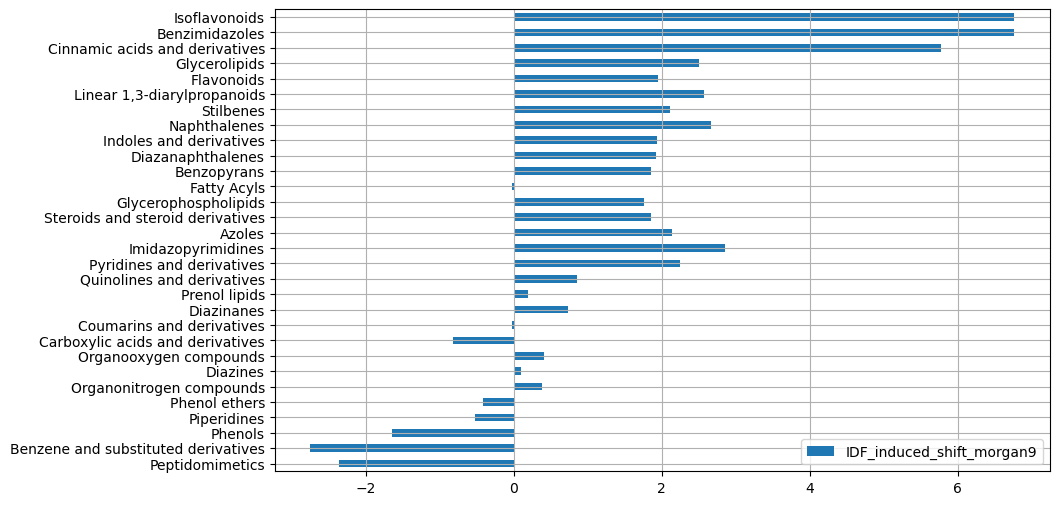

In [166]:
fig, ax = plt.subplots(figsize=(10,6))

df_per_class.iloc[:30, :].sort_values(
    "IDF_induced_shift_morgan3", ascending=True).plot(
    kind="barh", y = "IDF_induced_shift_morgan9", ax=ax)
plt.grid(True)
#plt.title(f"Relative shift of fraction of same-class-nearest neighbors (k={K})")

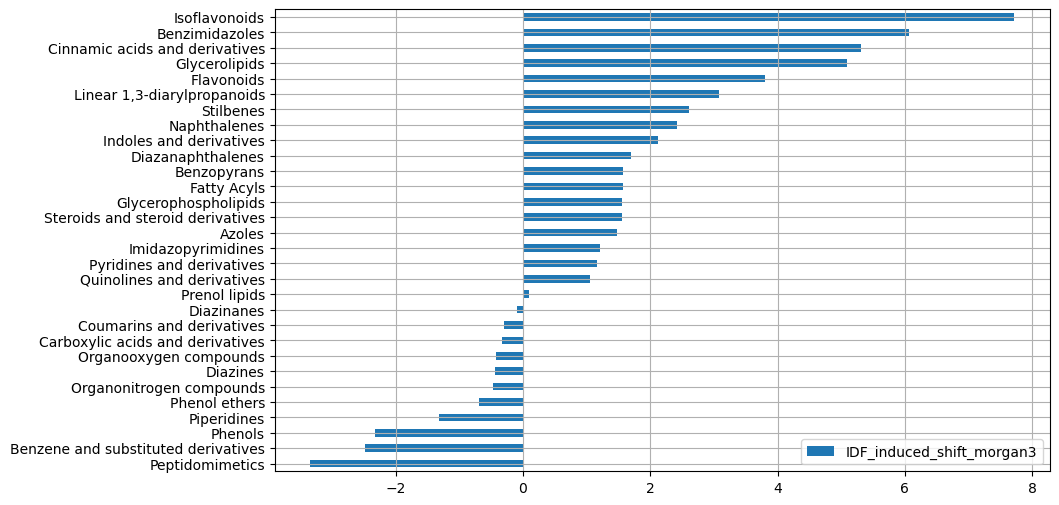

In [167]:
fig, ax = plt.subplots(figsize=(10,6))

df_per_class.iloc[:30, :].sort_values(
    "IDF_induced_shift_morgan3", ascending=True).plot(
    kind="barh", y = "IDF_induced_shift_morgan3", ax=ax)
plt.grid(True)
#plt.title(f"Relative shift of fraction of same-class-nearest neighbors (k={K})")

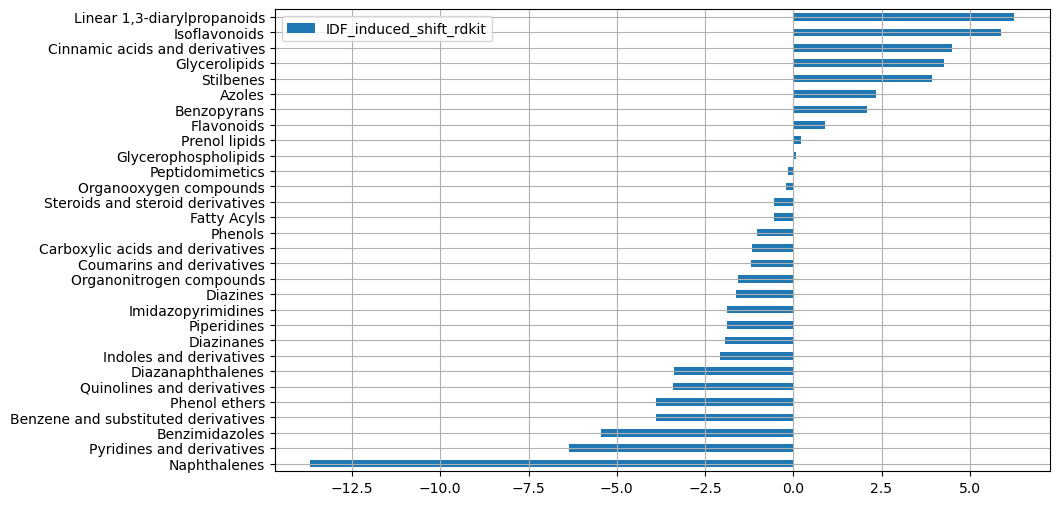

In [168]:
fig, ax = plt.subplots(figsize=(10,6))

df_per_class.iloc[:30, :].sort_values(
    "IDF_induced_shift_rdkit", ascending=True).plot(
    kind="barh", y = "IDF_induced_shift_rdkit", ax=ax)
plt.grid(True)
#plt.title(f"Relative shift of fraction of same-class-nearest neighbors (k={K})")

In [195]:
df_per_class.sort_values("counts")

,morgan3,morgan9,morgan3_tfidf,morgan9_tfidf,rdkit,rdkit_tfidf,counts,IDF_induced_shift_morgan3,IDF_induced_shift_morgan9,IDF_induced_shift_rdkit
Thiocyanates,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000
(3'->5')-dinucleotides and analogues,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000
Cycloheptafurans,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000
Dioxepanes,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000
Isothiochromanes,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
Organooxygen compounds,25.605681,26.859447,25.187337,27.268930,30.249234,30.039113,1596,-0.418344,0.409483,-0.210121
Fatty Acyls,58.499001,52.700183,60.064870,52.672850,68.354623,67.794603,1663,1.565869,-0.027333,-0.560020
Prenol lipids,68.434636,68.493113,68.523522,68.688038,65.881899,66.091248,2591,0.088886,0.194925,0.209349
Carboxylic acids and derivatives,63.928907,62.457802,63.605453,61.640890,64.000221,62.841530,4575,-0.323453,-0.816912,-1.158691


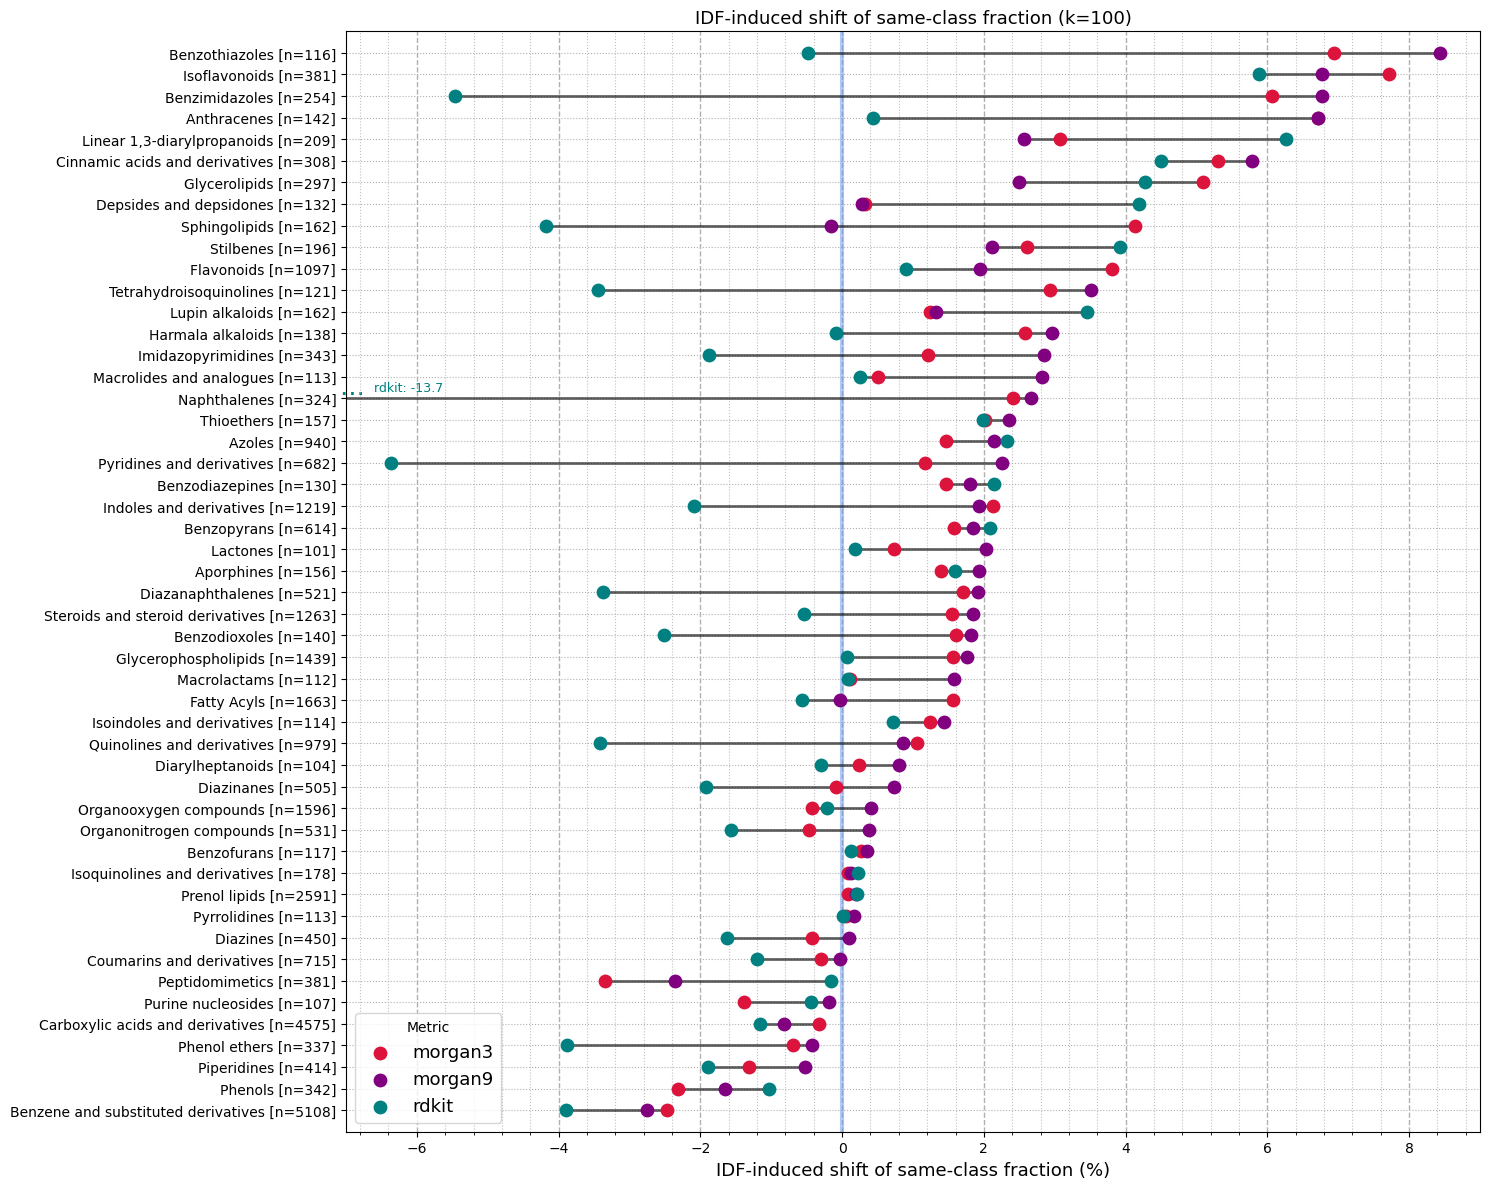

In [259]:
from matplotlib.ticker import AutoMinorLocator


basekeys = ["morgan3", "morgan9", "rdkit"]
colors = {
    "morgan3": "crimson",
    "morgan9": "purple",
    "rdkit": "teal",
}

cols = [f"IDF_induced_shift_{bk}" for bk in basekeys]

N = 50
sort_key = "max_shift" #"IDF_induced_shift_morgan3" #"counts"

df_plot = (
    df_per_class#.loc[:, cols]
    .iloc[:N, :]
    .sort_values(sort_key, ascending=True)
)

y = np.arange(len(df_plot.index))


# Plot
fig, ax = plt.subplots(figsize=(15, 0.2 * len(df_plot) + 2))

# Baseline at 0
ax.axvline(0, linewidth=3, color="cornflowerblue", alpha=0.5)

# Line spanning leftmost<->rightmost dot per class (min->max across metrics)
xmin = df_plot.loc[:, cols].min(axis=1).to_numpy(dtype=float)
xmax = df_plot.loc[:, cols].max(axis=1).to_numpy(dtype=float)
ax.hlines(y, xmin, xmax, color="black", linewidth=2, alpha=0.6)

# Dots
for bk, col in zip(basekeys, cols):
    x = df_plot[col].to_numpy(dtype=float)
    ax.scatter(x, y, s=80, color=colors[bk], label=bk, zorder=3)

# Crop limits you want to show
xlo, xhi = -7, 9
ax.set_xlim(xlo, xhi)

# Detect & annotate out-of-range points (left/right)
pad = 0.25  # how far inside the axis to place the "..." marker
for bk, col in zip(basekeys, cols):
    x = df_plot[col].to_numpy(dtype=float)

    # indices of outliers (beyond crop)
    left_idx = np.where(x < xlo)[0]
    right_idx = np.where(x > xhi)[0]

    for i in left_idx:
        y_i = y[i]
        x_true = x[i]
        x_edge = xlo + pad

        # "..." continuation at edge
        ax.text(x_edge, y_i + 0.5, "…", color=colors[bk], fontsize=18,
                va="center", ha="right", zorder=1)

        # small label for the true value (and metric)
        ax.text(x_edge + 0.15, y_i + 0.5, f"{bk}: {x_true:.1f}",
                color=colors[bk], fontsize=9, va="center", ha="left", zorder=5)

    for i in right_idx:
        y_i = y[i]
        x_true = x[i]
        x_edge = xhi - pad

        ax.text(x_edge, y_i, "…", color=colors[bk], fontsize=18,
                va="center", ha="left", zorder=1)

        ax.text(x_edge - 0.15, y_i, f"{bk}: {x_true:.1f}",
                color=colors[bk], fontsize=9, va="center", ha="right", zorder=5)


ax.set_yticks(y)
ax.set_yticklabels([f"{df_plot.index.values[i]} [n={df_plot.counts.values[i]}]" for i in range(N)])

ax.set_xlabel("IDF-induced shift of same-class fraction (%)", fontsize=13)
ax.set_title(f"IDF-induced shift of same-class fraction (k=100)", fontsize=13)

# Major + minor x gridlines
ax.grid(True, axis="y", linestyle=":", linewidth=.8)
ax.grid(True, axis="x", which="major", linestyle="--", linewidth=1.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(True, axis="x", which="minor", linestyle=":", linewidth=0.8, alpha=0.8)
ax.tick_params(axis="x", which="minor", labelbottom=False)

ax.legend(title="Metric", frameon=True, fontsize=13)

plt.ylim(-1, N)
plt.tight_layout()
plt.savefig("idf_induced_same_class_fraction_shift_k100.png", dpi=400)
plt.show()
